# Assignment 6.1

Name:  
Date:

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 6.1.

For the Scottish hill `Races` data, a linear model can predict men’s record times from women’s record times.  
http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat


(a)  Show the scatterplot and report the prediction equation. Predict the men’s record time for the Highland Fling, for which timeW = 490.05 minutes.


`Your answer goes here`


The predicted equations is
y_hat = b0_hat + b1_hat * x0 = 423.94
w/ b0_hat = -2.83,  b1_hat = 0.87 and x0=490.05
      


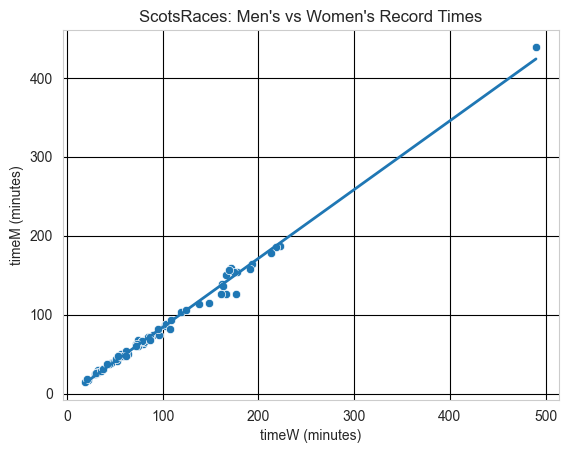

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import dedent

def read_file(path):
    """
    Reads file
    ----------------------------
    INPUT:
        path: (str)

    OUTPUT:
        (pd.DataFrame)
    """
    try:
        if path.endswith(".csv"):
            return pd.read_csv(path)

        elif path.endswith(".dat"):
            return pd.read_csv(path, sep="\s+")

        else:
            raise ValueError("File must end with .csv or .dat")

    except Exception as err:
        print(f"\nOOPS! -> {err}")

        return None

def sample_mean(var):
    """
    Returns the mean of the input variable (sample mean in this case).
    """
    # INput validation
    if not isinstance(var, pd.Series):
        raise("Input not valid\nNot a pandas Series")

    return var.mean()

def sample_stats(x, y):
    """
    Computes the sample means and samples Standard Errors.
    ---------------------------------------------
    INPUT:
        x: (pd.Series)
        y: (pd.Series)
    
    OUTPUT:
        (x_bar, y_bar, sxx, sxy, syy): (tuple)
    """
    # Sample means
    x_bar, y_bar = sample_mean(x), sample_mean(y)

    # Sample standard deviations
    sxx = np.sum((x - x_bar)**2)
    sxy = np.sum((x - x_bar) * (y - y_bar))
    syy = np.sum((y - y_bar)**2)

    return x_bar, y_bar, sxx, sxy, syy

def linear_fit(x_bar, y_bar, sxx, sxy):
    """
    Fits the model using least squares.
    
    WHY THE MATH, MATHS:
    -------------------
    b1_hat = sxy / sxx
        = (sum((xi - x_bar) * (yi - y_bar)) / sum((xi - x_bar)^2)
    b0_hat = y_bar - b1_hat * x_bar
    --------------------------------------------------------
    INPUT:
        x_bar: (np.float)
        y_bar: (np.float)
        sxx: (np.float)
        sxy: (np.float)

    OUTPUT:
        (b0_hat, b1_hat): (tuple)
    """
    # Estimate parameters
    b1_hat = sxy / sxx
    b0_hat = y_bar - b1_hat * x_bar

    return b0_hat, b1_hat

def correlation(Sxx, Sxy, Syy):
    """
    Computes sample correlation (r).

    r = Sxy / sqrt(Sxx * Syy)
    ----------------------------------
    INPUT:
        Sxx: (np.float)
        Sxy: (np.float)
        syy: (np.float)
        
    OUTPUT:
        r: (np.float) Correlation
    """
    # Division by zero case
    if np.sqrt(Sxx * Syy) != 0:
        return Sxy / np.sqrt(Sxx * Syy)

    else:
        print("Cannot divide by zero!")
        return None


def line_thru_origin(x, y):
    """
    Fits the no-intercept line through the origin.
    yi = b_1 * xi

    With b_0 = 0, we minimize LEAST SQUARES: sum(yi - b_1 * xi)**2,
    by taking derivative: -2*sum(xi*yi) + 2*b_1*sum(xi**2)
    -------------------------------------------------
    INPUT:
        x: (pd.Series) Expanatory variables
        y: (pd.Series) Target

    OUTPUT:
        b_hat: (np.float)
    """
    b_hat = np.sum(x * y) / sum(x**2)

    return b_hat

# =========== Main ==============
# Load data
df = read_file("./ScotsRaces.dat")

# Explanatory/Target variables
X = df["timeW"] # Women's time in minutes
y = df["timeM"] # Men's time in minutes

# Sample means and sample standard deviations
x_bar, y_bar, sxx, sxy, syy  = sample_stats(X, y)

# a) ======= Fit model and prediction equation ========
# Estimating parameters
b0_hat, b1_hat = linear_fit(x_bar, y_bar, sxx, sxy)

# Set white background with black grid
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(df, x="timeW", y="timeM")

# Fitted line: y_hat = b0_hat + b1_hat * x (over 200 evenly spaced values)
x_line = np.linspace(X.min(), X.max(), 200)
# Line to go on scatterplot
y_line = b0_hat + b1_hat * x_line

# Plotting
plt.plot(x_line, y_line, linewidth=2)

plt.title("ScotsRaces: Men's vs Women's Record Times")
plt.xlabel("timeW (minutes)")
plt.ylabel("timeM (minutes)")
#plt.show()

# Predict men's time for HighlandFling while timeW=490.05
x0 = 490.05

# Equation
y_hat = b0_hat + b1_hat * x0

# Output
print(f"""
The predicted equations is
y_hat = b0_hat + b1_hat * x0 = {y_hat:.2f}
w/ b0_hat = {b0_hat:.2f},  b1_hat = {b1_hat:.2f} and x0={x0}
      """)


(b) Find and interpret the correlation.

`Your answer goes here`

In [7]:
# b) ======= Correlation ===========
# Correlation
r = correlation(sxx, sxy, syy)

print(dedent(f"""
b) Correlation:
r = {r:.2f}

INTERPRETATION:
Very strong linear association between timeW and timeM.
In fact, it's nearly perfectly associated (almost 1) with sign (+), meaning
when women take longer in a race, so do men.

The COEFFICIENT OF DETERMINATION (r^2) ~ {r**2:.2f} is approx.
{(r**2) * 100:.1f}%, which is the proportion of variaibility in men's record
times EXPLAINED by the linear relationship with women's times, where only 
about {(1 - r**2)*100:.1f}% of is UNEXPLAINED (SSE).
             """))



b) Correlation:
r = 1.00

INTERPRETATION:
Very strong linear association between timeW and timeM.
In fact, it's nearly perfectly associated (almost 1) with sign (+), meaning
when women take longer in a race, so do men.

The COEFFICIENT OF DETERMINATION (r^2) ~ 0.99 is approx.
99.2%, which is the proportion of variaibility in men's record
times EXPLAINED by the linear relationship with women's times, where only 
about 0.8% of is UNEXPLAINED (SSE).



(c) We could impose the natural constraint that when timeW = 0, then timeM = 0. Fit the model $E(Y_i)=\beta x_i.$ Interpret the estimated slope.

`Your answer goes here`

In [8]:
# Intercept set to zero imposing the constraint timeW = 0 = timeM
b_hat = line_thru_origin(X, y)


print(dedent(f"""\n
c) No intercept, where we minimize the least squares, which becomes:
sum((yi - b_1 * xi)**2). E(Y) = b1_hat*x forces the regression line through the
origin. This makes sense, physically, since a running at 0 m/s would imply
you're not moving at all and if two people are racing, if one
isn't moving neither is the other.

Taking the derivative: 
-2*xi [sum(xi * yi) - b_1 * sum(xi**2)]

Setting to zero and solving for b_hat:
b_hat = sum(xi * yi) / sum(xi**2)

Therefore, b_hat = {b_hat:.2f}

INTERPRETATION:
--------------
b_hat, where there's no intercept so the baseline is adjusted and b_hat is
basically a scaling factor, where men's time is a FIXED proportion
of women's time.  Analogous to solving for acceleration in into physics, where
you start with the equation v = v0 + (1/2)*a*t^2 nad v0 = 0
(initially at rest).

Men are approximately {(1-b_hat)*100:.1f}% faster than women.
If b_hat = {b_hat:.2f}, men complete races about {b_hat*100:.1f}%
of the time it takes women.

In part a) With b_hat = {b_hat:.2f}, the model predicts men's
record times are approx. {b_hat:.2f} of women's times, across
all races.  
Also, men complete the races nearly {(1-b_hat)*100:.1f}% faster than women.

Unlike in the model in a), where the intercept b0_hat = {b0_hat:.2f} causes the
men-to-women time ratio to vary with the length of the race, and the one
without the intercept has a singe scaling factor, which is a stronger
assumption.
             """))




c) No intercept, where we minimize the least squares, which becomes:
sum((yi - b_1 * xi)**2). E(Y) = b1_hat*x forces the regression line through the
origin. This makes sense, physically, since a running at 0 m/s would imply
you're not moving at all and if two people are racing, if one
isn't moving neither is the other.

Taking the derivative: 
-2*xi [sum(xi * yi) - b_1 * sum(xi**2)]

Setting to zero and solving for b_hat:
b_hat = sum(xi * yi) / sum(xi**2)

Therefore, b_hat = 0.85

INTERPRETATION:
--------------
b_hat, where there's no intercept so the baseline is adjusted and b_hat is
basically a scaling factor, where men's time is a FIXED proportion
of women's time.  Analogous to solving for acceleration in into physics, where
you start with the equation v = v0 + (1/2)*a*t^2 nad v0 = 0
(initially at rest).

Men are approximately 14.8% faster than women.
If b_hat = 0.85, men complete races about 85.2%
of the time it takes women.

In part a) With b_hat = 0.85, the model predicts men's

## Problem 6.2.

For advanced industrialized nations, the Firearms data file at the text website shows annual homicide rates (per million population) and the number of firearms (per 100 people), with data taken from Wikipedia and [smallarmssurvey.org](smallarmssurvey.org).

(a) Construct a scatterplot and highlight any observations that fall apart from the general trend.

`Your answer goes here`

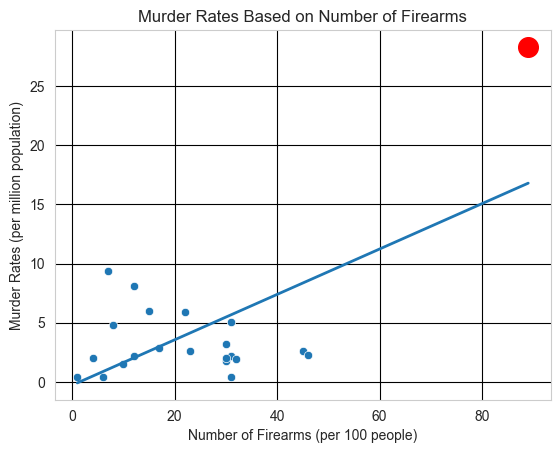


The US is the outlier of the 22 
advanced industrial nations with 89 firearms per 
100 people and 28.3 murders for a population of a million people.

WIth a sample size of only 22, a single outlier like the US
will strongly influence the correlation and regression fit.



In [16]:
df = read_file("./firearms.dat")
# Proper column name
df["murder_rates"] = df["deaths"]
# Drop redundant column
df.drop(labels="deaths", axis=1, inplace=True)

# a) Scatterplot and outliers; Two CONTINUOUS datatypes
X = df["firearms"] # per 100 people
y = df["murder_rates"] # per 1E6 population

# Sample means and sample standard deviations
x_bar, y_bar, sxx, sxy, syy  = sample_stats(X, y)

# Estimating parameters
b0, b1 = linear_fit(x_bar, y_bar, sxx, sxy)

# Set white background with black grid
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(data=df, x="firearms", y="murder_rates")

# Fitted line: y_hat = b0 + b1 * x (over 200 evenly spaced values)
x_line = np.linspace(X.min(), X.max(), 200)
# Line to go on scatterplot
y_line = b0 + b1 * x_line

# Highlight outlier (largest firearms value)
outlier = df.loc[df["firearms"].idxmax()]

plt.scatter(outlier["firearms"],
            outlier["murder_rates"],
            color="red",
            s=200)

# Plotting
plt.plot(x_line, y_line, linewidth=2)

plt.title("Murder Rates Based on Number of Firearms")
plt.xlabel("Number of Firearms (per 100 people)")
plt.ylabel("Murder Rates (per million population)")
plt.show()

# Outlier observation
print(dedent(f"""
The {outlier["Nation"]} is the outlier of the {df.shape[0]} 
advanced industrial nations with {X.max()} firearms per 
100 people and {outlier["murder_rates"]} murders for a population of a million people.

WIth a sample size of only {len(df)}, a single outlier like the US
will strongly influence the correlation and regression fit.
             """))


(b) Find the correlation with and without the outlying observation. Why is it so different in the two cases?

`Your answer goes here`

In [18]:
# b) Correlation with and without outlier
# With outlier
corr = correlation(sxx, sxy, syy)

# Outlier narrative
x, y = outlier["firearms"], outlier["murder_rates"]

# Interpretation
print(dedent(f"""
INTERPRETATION
--------------
With the outlier ({outlier["Nation"]}),
the correlation is {corr:.3f}.
This is interesting, given that the outlier is so far outside the majority of
observations. You'd think it would be A LOT closer to 1.

Since, for the US, the firearms (per 100 people) {x} and 
the murder rate (per million population) {y} are relatively so large,
the term in the numerator (Covariance) raises the correlation to such an extent that
it influences the analysis drastically.

Geometrcially, the correlation can be shown as r = cos(theta), where theta is
the angle between xi - x_bar and yi - y_bar.  The US rotates the direction of
the x-vector profoundly.
             """))

# Dataframe without outlier
no_us = df[df["Nation"] != "US"]

# Sample statistics
X2 = no_us["firearms"]
y2 = no_us["murder_rates"]

x2_bar, y2_bar, sxx2, sxy2, syy2 = sample_stats(X2, y2)

# Estimating parameters without US
b0_nous, b1_nous = linear_fit(x2_bar, y2_bar, sxx2, sxy2)

# Correlation without US
corr_nous = correlation(sxx2, sxy2, syy2)




INTERPRETATION
--------------
With the outlier (US),
the correlation is 0.634.
This is interesting, given that the outlier is so far outside the majority of
observations. You'd think it would be A LOT closer to 1.

Since, for the US, the firearms (per 100 people) 89 and 
the murder rate (per million population) 28.3 are relatively so large,
the term in the numerator (Covariance) raises the correlation to such an extent that
it influences the analysis drastically.

Geometrcially, the correlation can be shown as r = cos(theta), where theta is
the angle between xi - x_bar and yi - y_bar.  The US rotates the direction of
the x-vector profoundly.



(c) Fit the linear regression model with and without the outlying observation, and note how influential an outlier can be on the fit.

`Your answer goes here`

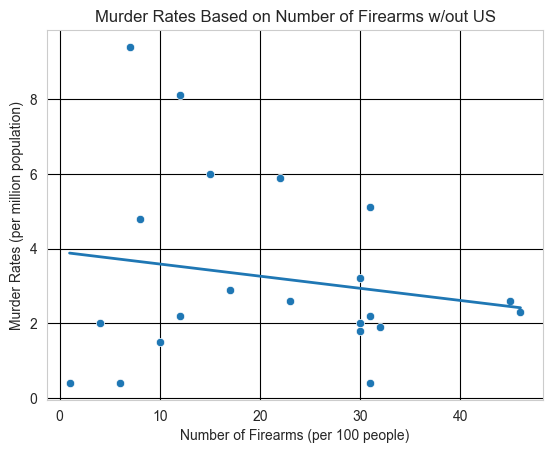


WITH outlier (US included):
    y_hat = b0 + b1 * x
    y_hat = -0.27 + 0.19 * x

WITHOUT outlier (US removed):
    y_hat = b0_noUS + b1_noUS * x
    y_hat = 3.91 + -0.03 * x

Without the outlier US, the correlation
is now -0.18!
y_hat = -0.27

Change in intercept:  delta_b0 = b0 - b0_noUS = -4.18
Change in slope:      delta_b1 = b1 - b1_noUS = 0.22

That is, the correlation without the US is NEGATIVE, which means
that the more firearms advanced nation's (otherthan the US) citizens possess,
the lower the murder rate!!      (>▽<)

An observation is influential if the removing it largely changes the slope,
intercept, or correlation.
The US in this case has an extreme x value and large cross-product Sxy.

Thus, correlation and least squares regression do not seem to be robust, given
this problem.



In [19]:
# c) Fitting the linear regression model without the outlier
X_line2 = np.linspace(X2.min(), X2.max(), 200)
# Line
y_line2 = b0_nous + b1_nous * X_line2

# Scatterplot without the US
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(no_us, x="firearms", y="murder_rates")

# Plotting
plt.plot(X_line2, y_line2, linewidth=2)

plt.title("Murder Rates Based on Number of Firearms w/out US")
plt.xlabel("Number of Firearms (per 100 people)")
plt.ylabel("Murder Rates (per million population)")
plt.show()

# Comparison of outlier influence
delt_b0 = b0 - b0_nous
delt_b1 = b1 - b1_nous

# Interpretation via the difference between w/ outlier and without
print(dedent(f"""
WITH outlier (US included):
    y_hat = b0 + b1 * x
    y_hat = {b0:.2f} + {b1:.2f} * x

WITHOUT outlier (US removed):
    y_hat = b0_noUS + b1_noUS * x
    y_hat = {b0_nous:.2f} + {b1_nous:.2f} * x

Without the outlier {outlier["Nation"]}, the correlation
is now {corr_nous:.2f}!
y_hat = {b0:.2f}

Change in intercept:  delta_b0 = b0 - b0_noUS = {delt_b0:.2f}
Change in slope:      delta_b1 = b1 - b1_noUS = {delt_b1:.2f}

That is, the correlation without the US is NEGATIVE, which means
that the more firearms advanced nation's (otherthan the US) citizens possess,
the lower the murder rate!!      (>▽<)

An observation is influential if the removing it largely changes the slope,
intercept, or correlation.
The US in this case has an extreme x value and large cross-product Sxy.

Thus, correlation and least squares regression do not seem to be robust, given
this problem.
             """))

## Problem 6.5.

For the `Covid19` data file at the text website:  
http://stat4ds.rwth-aachen.de/data/Covid19.dat 

(a) Construct the two scatterplots shown in Figure 6.3.

`Your answer goes here`

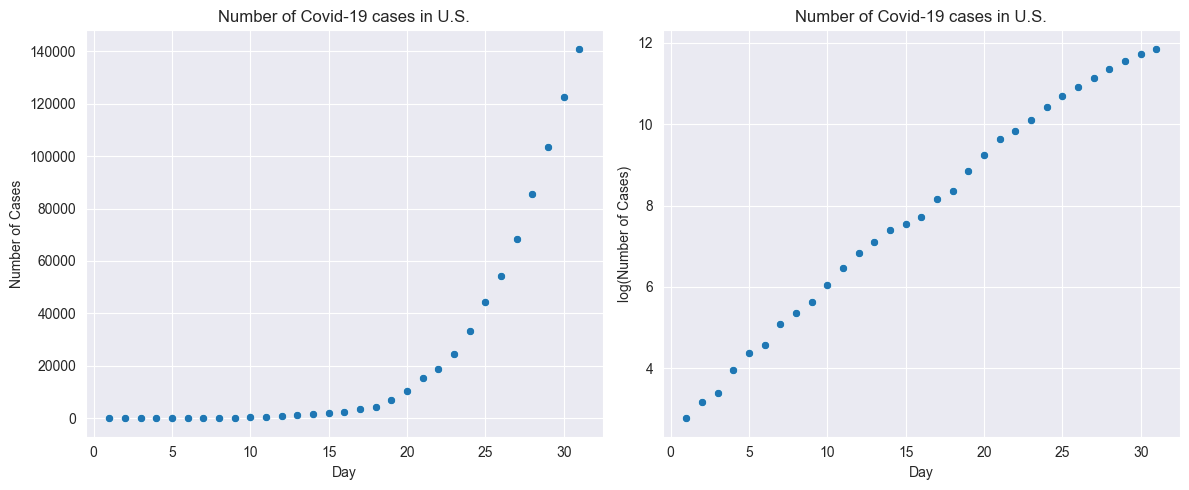

In [20]:
df = read_file("./covid19.dat")

# Explanatory/Target
X = df["day"]
y = df["cases"]

# Log transformation
log_y = np.log(y)

# a) ==== Scatter plots ====
# Add gridlines cuz i want to  ( ͡° ͜ʖ ͡°)
sns.set_style("darkgrid") # Must be BEFORE the figure 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
# Using pre-existing axes for plot
sns.scatterplot(data=df, x="day", y="cases", ax=ax1)
ax1.set(title="Number of Covid-19 cases in U.S.", xlabel="Day", ylabel="Number of Cases")

# Plot 2
sns.scatterplot(data=df, x="day", y=log_y, ax=ax2)
ax2.set(title="Number of Covid-19 cases in U.S.", xlabel="Day", ylabel="log(Number of Cases)")

plt.tight_layout()
plt.show()


(b) Find and interpret the correlation between time and (i) cases, (ii) log(cases).

`Your answer goes here`

In [22]:
# b) ====== Correlation and interpretation ========
# Sample stats
x_bar, y_bar, sxx, sxy, syy  = sample_stats(X, y)
x_bar_log, y_bar_log, sxx_log, sxy_log, syy_log  = sample_stats(X, log_y)

# Correlation for each case
corr1 = correlation(sxx, sxy, syy)
corr2 = correlation(sxx_log, sxy_log, syy_log)


print(dedent(f"""
---------------
INTERPRETATION
---------------
The correlation of original y: {corr1:.3f} and the correlation for
the log(y) is {corr2:.3f}.
This shows that the linear correlation underestimates the true strength of the
association between the number of days Covid has been actively circulating
through the given population and the number of cases reported.

The correlation is much closer to 1 after doing a log-transformation to the
exponential function, getting a linear relationship as shown by the scatter
plots.
             """))




---------------
INTERPRETATION
---------------
The correlation of original y: 0.794 and the correlation for
the log(y) is 0.997.
This shows that the linear correlation underestimates the true strength of the
association between the number of days Covid has been actively circulating
through the given population and the number of cases reported.

The correlation is much closer to 1 after doing a log-transformation to the
exponential function, getting a linear relationship as shown by the scatter
plots.



(c)  Fit the linear model for the log-transformed counts and report the prediction equation.$^{29}.$ Explain why the predicted count at day $x+1$ equals the predicted count at day $x$ multiplied by $\text{exp}(\hat\beta_1)=1.36.$

`Your answer goes here`

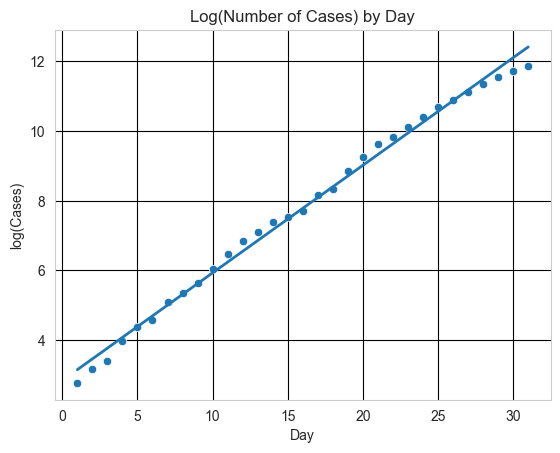

Each additional day multiplies predicted cases by 1.36.
log(y_hat) = 2.84 + 0.3088x
exp(beta1) = 1.36

Thus, the model predicts a 36.18% increase in cases per day
during the initial exponential growth phase.



In [23]:
# c) Linear Fit and prediction equation
b0_log, b1_log = linear_fit(x_bar_log, y_bar_log, sxx_log, sxy_log)

# Set white background with black grid
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(x=X, y=log_y)

# Fitted line: y_hat = b0 + b1 * x (over 200 evenly spaced values)
x_line = np.linspace(X.min(), X.max(), 200)
# Line to go on scatterplot
y_line_log = b0_log + b1_log * x_line

# Plotting
plt.plot(x_line, y_line_log, linewidth=2)
plt.title("Log(Number of Cases) by Day")
plt.xlabel("Day")
plt.ylabel("log(Cases)")
plt.show()

# Growth factor (exponential)
growth_factor = np.exp(b1_log)
print(f"Each additional day multiplies predicted cases by {growth_factor:.2f}.")

# Prediction equation
print(f"log(y_hat) = {b0_log:.2f} + {b1_log:.4f}x")
print(f"exp(beta1) = {np.exp(b1_log):.2f}")

pct_increase = (np.exp(b1_log) - 1) * 100
print(dedent(f"""
Thus, the model predicts a {pct_increase:.2f}% increase in cases per day
during the initial exponential growth phase.
"""))



## Problem 6.8.

Refer to the example in Section 6.2.5 of the crime rate in Florida counties.

(a) Explain what it means when we say these data exhibit *Simpson’s paradox*. What could cause this change in the direction of the association between crime rate and education
when we adjust for urbanization?

`Your answer goes here`


Simpson's Paradox is when the direction of an association reverses after adjusting for a confounding variable, which is a variable that is correlated with both the dependent variable and the independent variable.
Here, the marginal association between crime rate and education is positive,
meaning counties with higher education seem to exhibit higher crime rates.
When we adjust for urbanization, the association flips sign!  In this example, urbanization is the confounding variable.
This makes sense since more people in urban areas, more education opportunities and thus more crime.

Marginal Association: r(HS, Crime) = 0.47

W/in group (Ubran Stratification):
r(HS, Crime | LowUrban) = 0.25
             r(HS, Crime | Highurban) = 0.02

INTERPRETATION
--------------
Simpson's Paradox exists if the marginal correlation differs from in sign from the w/in group correlations.



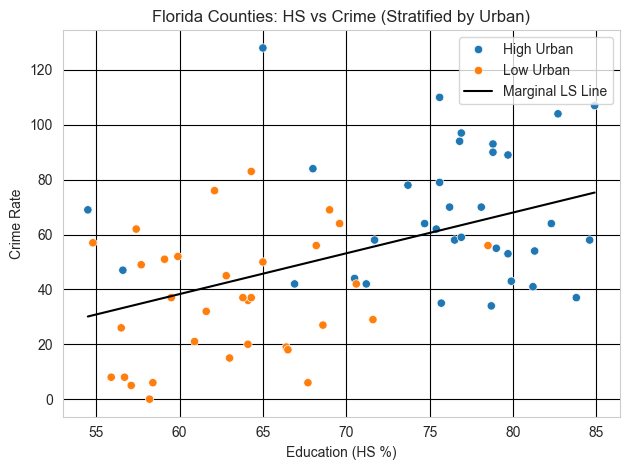

In [6]:
print(dedent(f"""
Simpson's Paradox is when the direction of an association reverses after adjusting for a confounding variable, which is a variable that is correlated with both the dependent variable and the independent variable.
Here, the marginal association between crime rate and education is positive,
meaning counties with higher education seem to exhibit higher crime rates.
When we adjust for urbanization, the association flips sign!  In this example, urbanization is the confounding variable.
This makes sense since more people in urban areas, more education opportunities and thus more crime.
             """))

df = read_file("./Florida.dat")

# Variables
X_ed = df["HS"]
X_urb = df["Urban"]
y_income = df["Income"]
y = df["Crime"]

# Marginal association
x_bar_a, y_bar_a, sxx_a, sxy_a, syy_a = sample_stats(X_ed, y)

# Correlation
corr_a = correlation(sxx_a, sxy_a, syy_a)

print(f"Marginal Association: r(HS, Crime) = {corr_a:.2f}")

# Stratefy Urban into two groups, splitting via median value
urb_cut = X_urb.median()
df["UrbanGroup"] = np.where(df["Urban"] >= urb_cut, "High Urban", "Low Urban")

# Correlations within strata
corr_by_group = {}
for g in ["Low Urban", "High Urban"]:
    sub = df[df["UrbanGroup"] == g]
    xb, yb, Sxx, Sxy, Syy = sample_stats(sub["HS"], sub["Crime"])
    corr_by_group[g] = correlation(Sxx, Sxy, Syy)

print(dedent(f"""
W/in group (Ubran Stratification):
r(HS, Crime | LowUrban) = {corr_by_group["Low Urban"]:.2f}
             r(HS, Crime | Highurban) = {corr_by_group["High Urban"]:.2f}

INTERPRETATION
--------------
Simpson's Paradox exists if the marginal correlation differs from in sign from the w/in group correlations.
             """))

# Plot: HS vs Crime colored by UrbanGroup + marginal LS line
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(data=df, x="HS", y="Crime", hue="UrbanGroup")

# Marginal least squares line for HS -> Crime
b0_a, b1_a = linear_fit(x_bar_a, y_bar_a, sxx_a, sxy_a)
x_line = np.linspace(X_ed.min(), X_ed.max(), 200)
y_line = b0_a + b1_a * x_line
plt.plot(x_line, y_line, color="black", label="Marginal LS Line")

plt.xlabel("Education (HS %)")
plt.ylabel("Crime Rate")
plt.title("Florida Counties: HS vs Crime (Stratified by Urban)")
plt.legend()
plt.tight_layout()
plt.show()



(b) Using the Florida data file, construct the scatterplot between *x* = education (HS) and *y* = income (Income), for which the correlation is 0.79. If we had data at the individual
level as well as aggregated for a county, sketch a scatterplot to show that at that level the correlation could be much weaker. So, predictions about individuals based on the
behavior of aggregate groups, known as the *ecological fallacy*, can be quite misleading.

`Your answer goes here`



Sample mean of HS: 69.49
Sample mean of Income: 24.51
Sxx = 5179.54
Sxy = 2170.13
Syy = 1447.26

Correlation: 0.79

Least Squares Line:
y_hat = -4.60 + 0.42x



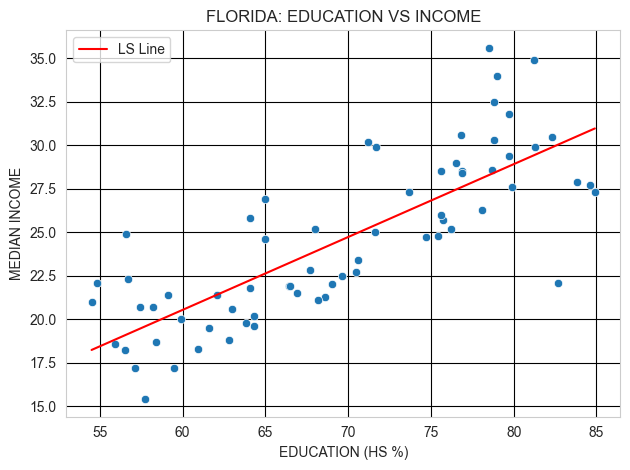



INTERPRETATION
--------------
The correlation 0.79 shows a strong positive linear association between county level education and median income.
Counties with more high school graduates tend to have larger incomes.  

Individual data would likely show a weaker correlation resulting from w/in-county  variation, as this is aggregated data.
Hence, ECOLOGICAL FALLACY, which is when information on individuals is falsely deduced from inference for the group they belong to.



In [7]:
# Sample stats for HS vs Income
x_bar_b, y_bar_b, sxx_b, sxy_b, syy_b = sample_stats(X_ed, y_income)
corr_b = correlation(sxx_b, sxy_b, syy_b)
b0_b, b1_b = linear_fit(x_bar_b, y_bar_b, sxx_b, sxy_b)

print(dedent(f"""\n
Sample mean of HS: {x_bar_b:.2f}
Sample mean of Income: {y_bar_b:.2f}
Sxx = {sxx_b:.2f}
Sxy = {sxy_b:.2f}
Syy = {syy_b:.2f}

Correlation: {corr_b:.2f}

Least Squares Line:
y_hat = {b0_b:.2f} + {b1_b:.2f}x
             """))

# Plotting: HS vs Income
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(data=df, x="HS", y="Income")

# regression line (your existing code is fine)
x_line = np.linspace(X_ed.min(), X_ed.max(), 200)
y_line = b0_b + b1_b * x_line
plt.plot(x_line, y_line, color="red", label="LS Line")

plt.xlabel("EDUCATION (HS %)")
plt.ylabel("MEDIAN INCOME")
plt.title("FLORIDA: EDUCATION VS INCOME")
plt.tight_layout()
plt.legend()
plt.show()

print(dedent(f"""\n
INTERPRETATION
--------------
The correlation {corr_b:.2f} shows a strong positive linear association between county level education and median income.
Counties with more high school graduates tend to have larger incomes.  

Individual data would likely show a weaker correlation resulting from w/in-county  variation, as this is aggregated data.
Hence, ECOLOGICAL FALLACY, which is when information on individuals is falsely deduced from inference for the group they belong to.
             """))



(c) Refer to (b), in which *x* falls between 54.5 and 84.9. Is it sensible to use the least squares line to predict a county’s median income if *x* = 0? Sketch a hypothetical true relationship between *x* and *E(Y)* to show the danger of *extrapolation*, using a fitted line to predict *E(Y)* far from the observed *x* values.

`Your answer goes here`

Observed range: 54.5 and 84.9

Predicted income when HS = 0: -4.60.

Since 0 is well outside the observed range of data, this prediction is EXTRAPOLATION.

The Least Squares model's linear assumptions only hold up for the observed data.  Outside, the true relationship could be non-linear.



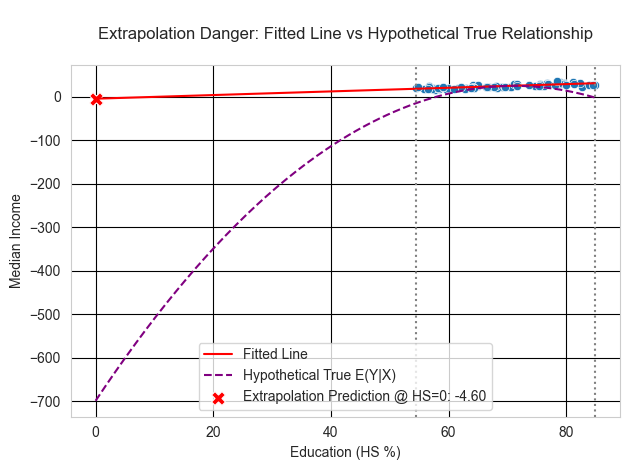

In [8]:
print(f"Observed range: {X_ed.min()} and {X_ed.max()}")

# x-value outside of range for extrapolation
x_out = 0
# y-extrapolation
y_ext = b0_b + b1_b * x_out
# Center of data
x_mid = (X_ed.min() + X_ed.max()) / 2

print(dedent(f"""
Predicted income when HS = 0: {y_ext:.2f}.

Since 0 is well outside the observed range of data, this prediction is EXTRAPOLATION.

The Least Squares model's linear assumptions only hold up for the observed data.  Outside, the true relationship could be non-linear.
             """))

# Hypothetical non-linearity
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(data=df, x="HS", y="Income")

# Nonlinear curve
x_curve = np.linspace(x_out, X_ed.max(), 200)
y_curve = b0_b + b1_b * x_curve

# Quadratic additive w/ negative constant so the curve is downward at the extremes
c = -1/7 # Arbitrarily chosen value to make divergence visible
y_curve_true = y_curve + c * (x_curve - x_mid)**2

# plot
plt.plot(x_curve, y_curve, color="red", label="Fitted Line")
plt.plot(
    x_curve, 
    y_curve_true, 
    color="purple", 
    linestyle="--",
    label="Hypothetical True E(Y|X)"
)

# Boundary lines for visualization
plt.axvline(
    X_ed.min(), 
    linestyle=":",
    color="gray"
)
plt.axvline(
    X_ed.max(),
    linestyle=":",
    color="gray"
)

# Extrapolatd prediction @ x=0
sns.scatterplot(
    x=[x_out],
    y=[y_ext],
    color="red", 
    marker="X",
    s=100,
    label=f"Extrapolation Prediction @ HS=0: {y_ext:.2f}"
               )

plt.xlabel("Education (HS %)")
plt.ylabel("Median Income")
plt.title(dedent("""
Extrapolation Danger: Fitted Line vs Hypothetical True Relationship
                 """))
plt.legend()
plt.tight_layout()
plt.show()


## Problem 6.10.

The `Students` data file shows responses on variables summarized in Exercise 1.2.

(a) Fit the linear model using *hsgpa* = high school GPA, *tv* = weekly hours watching TV, and *sport* = weekly hours participating in sports as predictors of *cogpa* = college GPA. Report the prediction equation. What do the *P*-values suggest?

`Your answer goes here`

In [10]:
import statsmodels.api as sm

df = read_file("./Students.dat")

# Predictors
X = df[["hsgpa", "tv", "sport"]]
# Target
y = df["cogpa"]

# a) ======= Fit the linear model ========
# Add constant (intercept) for statsmodels OLS
X_const = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X_const).fit()

# Summary
print(model.summary())

# Pull out the coefficients
b0 = model.params["const"]
b_hsgpa = model.params["hsgpa"]
b_tv = model.params["tv"]
b_sport = model.params["sport"]

print(dedent(f"""
Prediction Equation: 
cogpa_hat = {b0:.3f} + {b_hsgpa:.3f} * hsgpa + {b_tv:.3f} * tv + {b_sport:.3f} * sport

P-values:
p_hsgpa = {model.pvalues["hsgpa"]:.3f}
p_tv = {model.pvalues["tv"]:.3f}
p_sport = {model.pvalues["sport"]:.3f}

INTERPRETATION
--------------
             The p-value for hsgpa is {model.pvalues["hsgpa"]:.3f}, which is
 {"< 0.05 (statistically significant)" if model.pvalues['hsgpa'] < 0.05 else ">= 0.05 (not statistically significant)"}.
This suggests high school GPA {"IS" if model.pvalues['hsgpa'] < 0.05 else "is NOT"} a significant predictor of college GPA.

The p-value for tv is {model.pvalues['tv']:.3f}, which is {"< 0.05 (statistically significant)" if model.pvalues['tv'] < 0.05 else ">= 0.05 (not statistically significant)"}.
The p-value for sport is {model.pvalues['sport']:.3f}, which is {"< 0.05 (statistically significant)" if model.pvalues['sport'] < 0.05 else ">= 0.05 (not statistically significant)"}.

So hsgpa seems to be the main driver, while tv and sport
{"have" if model.pvalues['tv'] < 0.05 or model.pvalues['sport'] < 0.05 else "do NOT have"} strong evidence of being useful predictors
when hsgpa is already in the model.
             """))



                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.101
Time:                        16:04:55   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8154      0.368      7.655      0.0

(b)  Summarize the estimated effect of *hsgpa.*

`Your answer goes here`

In [11]:
print(dedent(f"""
Estimated effect of hsgpa:
b_hsgpa = {b_hsgpa:.3f}.

INTERPRETATION
---------------
For every unit increase in highschool gpa, the predicted college gpa increases
             by {model.conf_int().loc["hsgpa"][0]:.3f}, 
The 95% confidence interval for the hsgpa coefficient is:
[{model.conf_int().loc['hsgpa'][0]:.3f}, {model.conf_int().loc['hsgpa'][1]:.3f}]

Since this interval {"does NOT contain 0" if model.conf_int().loc['hsgpa'][0] > 0 or model.conf_int().loc['hsgpa'][1] < 0 else "contains 0"},
we {"can" if model.conf_int().loc['hsgpa'][0] > 0 or model.conf_int().loc['hsgpa'][1] < 0 else "cannot"} conclude the effect is statistically significant at alpha = 0.05.
             """))



Estimated effect of hsgpa:
b_hsgpa = 0.209.

INTERPRETATION
---------------
For every unit increase in highschool gpa, the predicted college gpa increases
             by 0.006, 
The 95% confidence interval for the hsgpa coefficient is:
[0.006, 0.412]

Since this interval does NOT contain 0,
we can conclude the effect is statistically significant at alpha = 0.05.



(c) Report and interpret $R^2$, adjusted $R^2$, and the multiple correlation.

`Your answer goes here`

In [12]:
R2 = model.rsquared
adj_R2 = model.rsquared_adj
multiple_corr = np.sqrt(R2)

print(dedent(f"""
R^2 = {R2:.3f}
Adjusted R^2 = {adj_R2:.4f}
Multiple Correlation (R) = sqrt(R^2) = {multiple_corr:.3f}

INTERPRETATION
--------------
             R^2 = {R2:.3f} means that {R2*100:.1f}% of the variability in college gpa is explained the linear model with hsgpa, tv, and sport, as predictors.
The remaining {(1-R2)*100:.1f}% is UNEXPLAINED.

Adjusted R^2 = {adj_R2:.3f} penalizes for the number of predictors.
It's {"close to" if abs(R2 - adj_R2) < 0.05 else "noticeably lower than"} R^2, which suggests
{"the extra predictors aren't adding much noise" if abs(R2 - adj_R2) < 0.05 else "some predictors may not be contributing much"}.

The multiple correlation R = {multiple_corr:.4f} is the correlation between
the observed college GPA values and the fitted (predicted) values from the model.
             
             """))



R^2 = 0.105
Adjusted R^2 = 0.0565
Multiple Correlation (R) = sqrt(R^2) = 0.323

INTERPRETATION
--------------
             R^2 = 0.105 means that 10.5% of the variability in college gpa is explained the linear model with hsgpa, tv, and sport, as predictors.
The remaining 89.5% is UNEXPLAINED.

Adjusted R^2 = 0.057 penalizes for the number of predictors.
It's close to R^2, which suggests
the extra predictors aren't adding much noise.

The multiple correlation R = 0.3233 is the correlation between
the observed college GPA values and the fitted (predicted) values from the model.




## Problem 6.12.

For the `UN` data file at the book’s website (see Exercise 1.24), construct a multiple regression model predicting Internet using all the other variables. Use the concept of multicollinearity to explain why adjusted $R^2$ is not dramatically greater than when GDP is the sole predictor. Compare the estimated GDP effect in the bivariate model and the multiple regression model and explain why it is so much weaker in the multiple regression model.

`Your answer goes here`

In [13]:
df = read_file("./UN.dat")

# Target var
y = df["Internet"]

# Numeric predictors
preds = [c for c in df.columns if c not in ["Nation", "Internet"]]
X = df[preds]

# Bivariate model
X_gdp = sm.add_constant(df[["GDP"]])
model_gdp = sm.OLS(y, X_gdp).fit()

print(model_gdp.summary())

# ====== Multiple Regression ======
X_all_const = sm.add_constant(X)
model_all = sm.OLS(y, X_all_const).fit()

print(model_all.summary())

# Comparing
b_gdp_bivar = model_gdp.params["GDP"]
b_gdp_multi = model_all.params["GDP"]

print(dedent(f"""
Bivariate:
    b_gdp = {b_gdp_bivar:.3f}
    R^2 = {model_gdp.rsquared:.3f}
    Adjusted R^2 = {model_gdp.rsquared:.3f}

Multiple (all predictors)a:
    b_GDP = {b_gdp_multi:.4f}
    R^2 = {model_all.rsquared:.4f}
    Adjusted R^2 = {model_all.rsquared_adj:.4f}

The adjusted R^2 isn't dramatically larger with all predictors because of Multicollinearity.
Predictors are highly correlated with HDI, negatively correlated with GII and
             fertility.  Becaause these predictors share quite a bit of
             overlapping information, adding them doesn't explain new
             variability in internet outside what GDP already explains.

Adjusted R^2 penalizes for each additional predictor so if the additional ones
             don't add much in terms of explanatory power, adjusted R^2 doesn't improve much.  It could even decrease!

The GDP effect is weaker in multiple regression because, 
in the bivariate model, b_gdp = {b_gdp_bivar:.3f}, which means each unit increase in GDP predicts a {b_gdp_bivar:.3f} increase in internet usage.

In the multiple regression model, the other variables are included, so GDP only
             deals with its unique partial effect on internet....  And since
             GDP shares a lot of information with those variables
             (multicollinearity), its unique contributions decreases.
             """))

# Correlation matrix and stuff
print("\nCorrelation matrix of predictors:")
print(X.corr().round(3))


                            OLS Regression Results                            
Dep. Variable:               Internet   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     133.5
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           2.55e-14
Time:                        16:26:50   Log-Likelihood:                -162.74
No. Observations:                  42   AIC:                             329.5
Df Residuals:                      40   BIC:                             333.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.1341      3.749      6.971      0.0

## Problem 7.1.

For the `Houses` data file described in Section 7.1.3, consider $Y$ = selling price, $x_1$ = tax bill (in dollars), and $x_2$ = whether the house is new.

(a) Form the scatterplot of $y$ and $x_1$. Does the normal GLM structure of constant variability in $y$ seem approproate? If not, how does it seem to be violated?

`Your answer goes here`

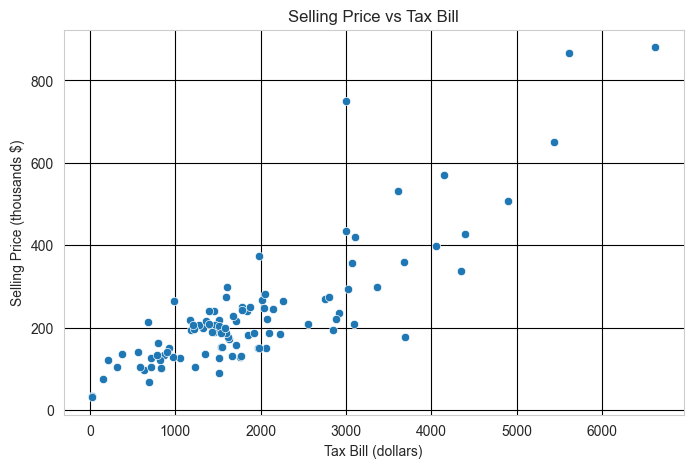


The scatter plot shows the variability in selling price increase sa the tax bill increases.  The spread of y values expands out to the right, which violates the constant variabililty assumptions of the normal GLM.

The variance seems to increase with the mean, implying there might be a model,
             where the variance is proprtional to a function of the mean (Gamma
            dist.).



In [14]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def read_file(path):
    """
    Reads file
    ----------------------------
    INPUT:
        path: (str)

    OUTPUT:
        (pd.DataFrame)
    """
    try:
        if path.endswith(".csv"):
            return pd.read_csv(path)

        elif path.endswith(".dat"):
            return pd.read_csv(path, sep="\s+")

        else:
            raise ValueError("File must end with .csv or .dat")

    except Exception as err:
        print(f"\nOOPS! -> {err}")

        return None

# ======= MAIN ===========
df = read_file("./Houses.dat")

# a) ======= Scatterplot ========
sns.set_style("whitegrid", {'grid.color': 'black'})
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="taxes", y="price")
plt.title("Selling Price vs Tax Bill")
plt.xlabel("Tax Bill (dollars)")
plt.ylabel("Selling Price (thousands $)")
plt.show()

print(dedent(f"""
The scatter plot shows the variability in selling price increase sa the tax bill increases.  The spread of y values expands out to the right, which violates the constant variabililty assumptions of the normal GLM.

The variance seems to increase with the mean, implying there might be a model,
             where the variance is proprtional to a function of the mean (Gamma
            dist.).
"""))



(b) Using the identity link function, fit the (i) normal GLM, (ii) gamma GLM. For each model, interpret the effect of $x_2$.

`Your answer goes here`

In [17]:
# Normal GLM
normal_glm = smf.glm(
    "price ~ taxes + new",
    data=df,
    family=sm.families.Gaussian()).fit()

print(normal_glm.summary())

# Gamma GLM
gamma_glm = smf.glm(
    "price ~ taxes + new",
    data=df,
    family=sm.families.Gamma(link=sm.families.links.Identity())).fit()

print(gamma_glm.summary())

# Coefficients
b_new_normal = normal_glm.params["new"]
b_new_gamma = gamma_glm.params["new"]

print(dedent(f"""
Normal GLM:
    b_new = {b_new_normal:.2f}
    A new house has a predicted selling price that is ${b_new_normal:.2f} thousand
  {"higher" if b_new_normal > 0 else "lower"} than a non-new house, controlling for tax bill.

Gamma GLM:
  b_new = {b_new_gamma:.2f}
  A new house has a predicted selling price that is ${b_new_gamma:.2f} thousand
  {"higher" if b_new_gamma > 0 else "lower"} than a non-new house, controlling for tax bill.

Both use the identity link, so the interpretation is additive in both cases.
The coefficient represents the expected change in price (thousands $) for
new vs. not-new houses, holding taxes constant.
    
             """))


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  price   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          6212.7
Method:                          IRLS   Log-Likelihood:                -577.09
Date:                Tue, 17 Feb 2026   Deviance:                   6.0264e+05
Time:                        16:48:24   Pearson chi2:                 6.03e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9333
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.9651     14.695      2.856      0.0

/Users/whitney/usd_ai/module6/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


(c) For each model, describe how the estimated variability in selling prices varies as the mean selling price varies from 100 thousand to 500 thousand dollars.

`Your answer goes here`

In [18]:
# Normal GLM
# Estimated sigma^2 from the normal GLM
sig2_norm = normal_glm.scale

# Gamma GLM: Var(Y) = phi * mu^2, where phi is the scale parameter
phi_gamma = gamma_glm.scale

mu_100 = 100
mu_500 = 500

# Normal GLM variance is constant
var_normal_100 = sig2_norm
var_normal_500 = sig2_norm

# Gamma GLM variance: Var(Y) = phi * mu^2
var_gamma_100 = phi_gamma * mu_100**2
var_gamma_500 = phi_gamma * mu_500**2

print(dedent(f"""
Estiamted variabililty @ different mean selling prices

Normal GLM:
    var(Y) = sig^2 = {sig2_norm:.2f} 
    SD at mu=100K: {np.sqrt(var_normal_100):.2f} thousand
    SD at mu=500K: {np.sqrt(var_normal_500):.2f} thousand

Gamma GLM:
    Var(Y) = phi * mu^2, where phi = {phi_gamma:.6f}
    At mu = 100K: Var = {phi_gamma:.6f} * 100^2 = {var_gamma_100:.2f}, SD = {np.sqrt(var_gamma_100):.2f} thousand
    At mu = 500K: Var = {phi_gamma:.6f} * 500^2 = {var_gamma_500:.2f}, SD = {np.sqrt(var_gamma_500):.2f} thousand

The Gamma GLM predicts a lot more variability at higher mean prices, and the SD
             @ mu=500K is 5 times the SD @ mu=100K, matching the spread's shape
             in the scatterplot.  
The normal GLM completey misses this. 
             """))



Estiamted variabililty @ different mean selling prices

Normal GLM:
    var(Y) = sig^2 = 6212.74 
    SD at mu=100K: 78.82 thousand
    SD at mu=500K: 78.82 thousand

Gamma GLM:
    Var(Y) = phi * mu^2, where phi = 0.087318
    At mu = 100K: Var = 0.087318 * 100^2 = 873.18, SD = 29.55 thousand
    At mu = 500K: Var = 0.087318 * 500^2 = 21829.58, SD = 147.75 thousand

The Gamma GLM predicts a lot more variability at higher mean prices, and the SD
             @ mu=500K is 5 times the SD @ mu=100K, matching the spread's shape
             in the scatterplot.  
The normal GLM completey misses this. 



(d) Which model is preferred according to AIC?

`Your answer goes here`

In [19]:
aic_normal = normal_glm.aic
aic_gamma = gamma_glm.aic

print(dedent(f"""
d) AIC comparison:
Normal GLM AIC = {aic_normal:.1f}
Gamma GLM AIC  = {aic_gamma:.1f}

The {"Gamma" if aic_gamma < aic_normal else "Normal"} GLM has the lower AIC
({min(aic_normal, aic_gamma):.1f} vs {max(aic_normal, aic_gamma):.1f}),
so it is PREFERRED.

This makes sense given the heteroscedasticity we observed in part (a).
The Gamma GLM better captures the increasing variance with the mean,
which the normal GLM's constant variance assumption fails to model.
             """))



d) AIC comparison:
Normal GLM AIC = 1160.2
Gamma GLM AIC  = 1104.7

The Gamma GLM has the lower AIC
(1104.7 vs 1160.2),
so it is PREFERRED.

This makes sense given the heteroscedasticity we observed in part (a).
The Gamma GLM better captures the increasing variance with the mean,
which the normal GLM's constant variance assumption fails to model.



## Problem 7.5.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the original observation.

(a) Does the survival of the sheep seem to depend on their weight? If so, how does the weight of a sheep affect its probability of survival? Answer by fitting a generalized linear model for the survival probability.

`Your answer goes here`

                 Generalized Linear Model Regression Results                  
Dep. Variable:               survival   No. Observations:                 1359
Model:                            GLM   Df Residuals:                     1357
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -645.22
Date:                Tue, 17 Feb 2026   Deviance:                       1290.4
Time:                        17:06:31   Pearson chi2:                 1.44e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1294
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0298      0.251     -8.103      0.0

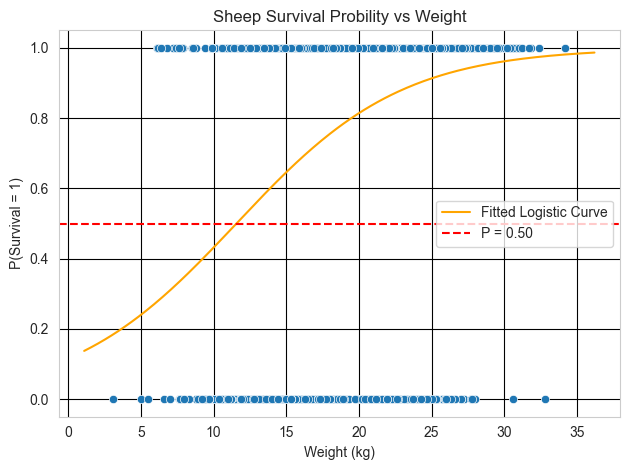


Logistic regression model:
log(p / (1 - p)) = -2.03 + 0.18 *weight

P-value for weight: 0.000,
which is < 0.05 (statistically significant).

So, survival does depend on weight.

The coefficient for weight is b1 = 0.1755 (positive).
This means that for each 1 kg increase in weight, the LOG-ODDS of survival
increase by 0.1755.

The odds ratio: exp(b1) = exp(0.1755) = 1.1918
This means for each additional kg, the ODDS of survival are multiplied by 1.1918.
Heavier sheep are more likely to survive.




In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from textwrap import dedent

def read_file(path):
    """
    Reads file
    ----------------------------
    INPUT:
        path: (str)

    OUTPUT:
        (pd.DataFrame)
    """
    try:
        if path.endswith(".csv"):
            return pd.read_csv(path)

        elif path.endswith(".dat"):
            return pd.read_csv(path, sep="\s+")

        else:
            raise ValueError("File must end with .csv or .dat")

    except Exception as err:
        print(f"\nOOPS! -> {err}")

        return None

# ======= MAIN ======
df = read_file("./Sheep.dat")

# a) ======= Fit logistic regression  =====
model = smf.glm(
    "survival ~ weight",
    data=df,
    family=sm.families.Binomial()).fit()

print(model.summary())

b0 = model.params["Intercept"]
b1 = model.params["weight"]

# Plotting the fitted logistic curve
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(data=df, x="weight", y="survival")

# Fitted probability curve
x_range = np.linspace(df["weight"].min() - 2, df["weight"].max() + 2, 300)
# Logistic function: P(Y=1) = exp(b0 + b1*x) / (1 + exp(b0 + b1*x))
logit_vals = b0 + b1 * x_range
prob_vals = np.exp(logit_vals) / (1 + np.exp(logit_vals))

plt.plot(x_range, prob_vals, color="orange", label="Fitted Logistic Curve")
plt.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    label="P = 0.50"
)

plt.title("Sheep Survival Probility vs Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("P(Survival = 1)")
plt.tight_layout()
plt.legend()
plt.show()

# Odds ratio
odds_ratio = np.exp(b1)

print(dedent(f"""
Logistic regression model:
log(p / (1 - p)) = {b0:.2f} + {b1:.2f} *weight

P-value for weight: {model.pvalues["weight"]:.3f},
which is {"< 0.05 (statistically significant)" if model.pvalues['weight'] < 0.05 else ">= 0.05"}.

So, survival does depend on weight.

The coefficient for weight is b1 = {b1:.4f} ({"positive" if b1 > 0 else "negative"}).
This means that for each 1 kg increase in weight, the LOG-ODDS of survival
{"increase" if b1 > 0 else "decrease"} by {abs(b1):.4f}.

The odds ratio: exp(b1) = exp({b1:.4f}) = {odds_ratio:.4f}
This means for each additional kg, the ODDS of survival are multiplied by {odds_ratio:.4f}.
{"Heavier sheep are more likely to survive." if b1 > 0 else "Heavier sheep are less likely to survive."}

             """))


(b)  For what weight values do the sheep have more than a 50% chance of survival?

`Your answer goes here`

In [21]:
# weight > -b0 / b1
weight_50 = -b0 / b1

print(dedent(f"""
At P = 0.50, the logit = 0: b0 + b1 * weight = 0
{b0:.3f} + {b1:.3f} * weight = 0
weight = {-b0:.3f} / {b1:.3f} = {weight_50:.2f} kg

Since the coefficient for weight is {"positive" if b1 > 0 else "negative"},
sheep with weight {">" if b1 > 0 else "<"} {weight_50:.2f} kg have MORE than a 50% chance
of survival.

So a sheep needs to weigh at least {weight_50:.2f} kg to have a better than
even chance of making it through the year.
             """))




At P = 0.50, the logit = 0: b0 + b1 * weight = 0
-2.030 + 0.175 * weight = 0
weight = 2.030 / 0.175 = 11.57 kg

Since the coefficient for weight is positive,
sheep with weight > 11.57 kg have MORE than a 50% chance
of survival.

So a sheep needs to weigh at least 11.57 kg to have a better than
even chance of making it through the year.



## Problem 7.9.

The `SoreThroat` data file at the book’s website contains data from from a study$^{23}$ about *Y* = whether a patient having surgery had a sore throat on waking (1 = yes, 0 = no) as a function of *D* = duration of the surgery (in minutes) and *T* = type of device used to secure the airway (1 = tracheal tube, 0 = laryngeal mask airway).

(a) Fit a GLM using both explanatory variables as main effects. Interpret effects.

`Your answer goes here`

In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def read_file(path):
    """
    Reads file
    ----------------------------
    INPUT:
        path: (str)

    OUTPUT:
        (pd.DataFrame)
    """
    try:
        if path.endswith(".csv"):
            return pd.read_csv(path)

        elif path.endswith(".dat"):
            return pd.read_csv(path, sep="\s+")

        else:
            raise ValueError("File must end with .csv or .dat")

    except Exception as err:
        print(f"\nOOPS! -> {err}")

        return None

# ======= MAIN ===========
df = read_file("./SoreThroat.dat")

# a) ======= Main effects model ========
model_main = smf.glm("Y ~ D + T",
                      data=df,
                      family=sm.families.Binomial()).fit()

print(model_main.summary())

b0 = model_main.params["Intercept"]
b_D = model_main.params["D"]
b_T = model_main.params["T"]

# Odds ratios
or_D = np.exp(b_D)
or_T = np.exp(b_T)

print(dedent(f"""
logit(P(sore throat)) = {b0:.4f} + {b_D:.4f} * D + {b_T:.4f} * T

Effect of Duration (D):
             b_D = {b_D:.3f} odds ratio = exp({b_D:.3f}) = {or_D:.3f}.
for each additional minute of surgery, the odds of a sore throat are multiplied
by {or_D:.3f}.
P-value = {model_main.pvalues["D"]:.3f}.

Effect of Device Type (T):
  b_T = {b_T:.4f}, odds ratio = exp({b_T:.4f}) = {or_T:.4f}
  Using a tracheal tube (T=1) vs laryngeal mask (T=0), the odds of
  a sore throat are multiplied by {or_T:.4f}, holding duration constant.
  {"Tracheal tube is associated with HIGHER odds of sore throat." if b_T > 0 else "Tracheal tube is associated with LOWER odds of sore throat."}
  p-value = {model_main.pvalues['T']:.4f} {"(significant)" if model_main.pvalues['T'] < 0.05 else "(not significant)"}


             """))


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.069
Date:                Tue, 17 Feb 2026   Deviance:                       30.138
Time:                        17:15:46   Pearson chi2:                     37.0
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3677
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4173      1.095     -1.295      0.1

(b) Fit a GLM permitting interaction between the explanatory variables. Interpret the effect of *D* at each category of *T*.

`Your answer goes here`

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       31
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.161
Date:                Tue, 17 Feb 2026   Deviance:                       28.321
Time:                        17:15:55   Pearson chi2:                     28.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3997
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0498      1.469      0.034      0.9

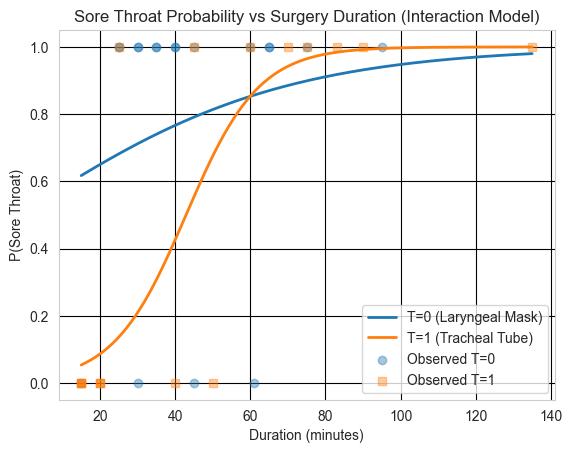

In [23]:
model_inter = smf.glm("Y ~ D + T + D:T",
                       data=df,
                       family=sm.families.Binomial()).fit()

print(model_inter.summary())

b0_i = model_inter.params["Intercept"]
b_D_i = model_inter.params["D"]
b_T_i = model_inter.params["T"]
b_DT_i = model_inter.params["D:T"]

print(dedent(f"""
logit(P(sore throat)) = {b0_i:.4f} + {b_D_i:.4f} * D + {b_T_i:.4f} * T + {b_DT_i:.4f} * D*T

Effect of Duration (D) at each category of T:

When T = 0 (laryngeal mask airway):
  logit(P) = {b0_i:.4f} + {b_D_i:.4f} * D
  Effect of D: b_D = {b_D_i:.4f}
  Odds ratio per minute = exp({b_D_i:.4f}) = {np.exp(b_D_i):.4f}
  For each extra minute, odds of sore throat {"increase" if b_D_i > 0 else "decrease"}
  by {abs(np.exp(b_D_i) - 1)*100:.1f}% with the laryngeal mask.

When T = 1 (tracheal tube):
  logit(P) = ({b0_i:.4f} + {b_T_i:.4f}) + ({b_D_i:.4f} + {b_DT_i:.4f}) * D
           = {b0_i + b_T_i:.4f} + {b_D_i + b_DT_i:.4f} * D
  Effect of D: b_D + b_DT = {b_D_i:.4f} + {b_DT_i:.4f} = {b_D_i + b_DT_i:.4f}
  Odds ratio per minute = exp({b_D_i + b_DT_i:.4f}) = {np.exp(b_D_i + b_DT_i):.4f}
  For each extra minute, odds of sore throat {"increase" if (b_D_i + b_DT_i) > 0 else "decrease"}
  by {abs(np.exp(b_D_i + b_DT_i) - 1)*100:.1f}% with the tracheal tube.

The interaction term (p = {model_inter.pvalues['D:T']:.4f}) suggests that
the effect of surgery duration on sore throat probability
{"DOES" if model_inter.pvalues['D:T'] < 0.05 else "does NOT significantly"} differ between the two device types.

             """))

# PLotting
sns.set_style("whitegrid", {'grid.color': 'black'})

d_range = np.linspace(df["D"].min(), df["D"].max(), 200)

# T = 0 (laryngeal mask)
logit_T0 = b0_i + b_D_i * d_range
prob_T0 = np.exp(logit_T0) / (1 + np.exp(logit_T0))

# T = 1 (tracheal tube)
logit_T1 = (b0_i + b_T_i) + (b_D_i + b_DT_i) * d_range
prob_T1 = np.exp(logit_T1) / (1 + np.exp(logit_T1))

plt.plot(d_range, prob_T0, linewidth=2, label="T=0 (Laryngeal Mask)")
plt.plot(d_range, prob_T1, linewidth=2, label="T=1 (Tracheal Tube)")

# Scatter the observed data
mask_T0 = df["T"] == 0
mask_T1 = df["T"] == 1
plt.scatter(df.loc[mask_T0, "D"], df.loc[mask_T0, "Y"], alpha=0.4, marker='o', label="Observed T=0")
plt.scatter(df.loc[mask_T1, "D"], df.loc[mask_T1, "Y"], alpha=0.4, marker='s', label="Observed T=1")

plt.title("Sore Throat Probability vs Surgery Duration (Interaction Model)")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(Sore Throat)")
plt.legend()
plt.show()





## 7.10 Predicting Diabetes Using Logistic Regression

In this exercise, you will build a simple AI classification model using logistic regression to predict whether a patient has diabetes. You will use the Diabetes dataset available directly from sklearn.datasets.

### Task

Load the diabetes dataset, explore the features, and build a logistic regression model that predicts the presence of diabetes.
Then, discuss whether logistic regression is appropriate for this AI task based on what we have covered in class.

### Your Steps

1. Load the diabetes dataset from sklearn.

2. Split the data into training and test sets.

3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

5. Write a short reflection: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

### Starter Code

1. Load the diabetes dataset from sklearn

In [29]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, classification_report)


# 1. Load the dataset
data = load_diabetes()

# Variables
X = pd.DataFrame(data.data, columns=data.feature_names)
# Continuous target
y_cont = pd.Series(data.target, name="target")

# Convert continuous target ot binary using median threshold
median_target = y_cont.median()
y = (y_cont > median_target).astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target median: {median_target}")
print(f"Class distribution:\n{y.value_counts()}")


Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target median: 140.5
Class distribution:
target
1    221
0    221
Name: count, dtype: int64


2. Split the data into training and test sets.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Training set: 353 samples
Test set: 89 samples


3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

In [31]:
# Scaling is important bc logistic regression is sensitive to feature magnitudes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]


4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

In [32]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Outputs
print(dedent(f"""
\nAccuracy: {accuracy:.3f}
F1 SCore: {f1:.3f}
Precision: {precision:.3f}
Recall: {recall:.3f}
roc auc: {roc_auc:.3f}
             """))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\nFeature Coefficients (scaled):")
print(coef_df.to_string(index=False))




Accuracy: 0.742
F1 SCore: 0.753
Precision: 0.714
Recall: 0.795
roc auc: 0.826


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.69      0.73        45
           1       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89


Feature Coefficients (scaled):
Feature  Coefficient
     s5     0.863100
    bmi     0.737994
     bp     0.719217
     s2     0.178080
    age     0.069721
     s4    -0.019727
     s6    -0.110004
     s3    -0.415655
    sex    -0.485845
     s1    -0.546749


5. Write a short reflectmion: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

print(dedent(f"""
\nREFLECTION:
             Logistic Regression has an accuracy of {accuracy:.3f} and ROC AUC
             of {roc_auc:.3f}.
{"These are reasonable results " if accuracy > .65 else "Results not so profound." }

ADVANTAGES FOR THIS PARTICULAR PROBLEM INCLUDE:
-------------------------------------------------
INTERPRETABILITY:
    Each coefficient tells us how a feature affects the log-odds of higher disease progression.

Binary outcomes naturally fit the logstic regression model, and with 10
             features and 442 samples, it's proper to use since it doesn't
             require a ton of data like deep learning.

LIMITATIONS:
-------------
Original targetn is continuous and thus lose information when we do the
             encoding.
Linear Refression would be better for a continuous target.
Muticollinaerity among features could inflate the coefficient variance,
             actually reducing interpretability.
             """))


&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{23}$ Described in “Binary Data” by D. Collett, *Encyclopedia of Biostatistics*, 2nd ed. (Wiley, 2005), pp. 439–446.

$^{29}$ Some lack of fit the last few days reflects the impact of increasing “social distancing.”